# 实验六：延迟对比与 MindStudio Profiling

本实验基于实验五已经验证通过的 `YoloNmsCustom`。这里要区分三个概念：

1. CPU NMS 算法时间：纯 Python/NumPy 的 NMS baseline。
2. ACLNN runner 端到端时间：执行 `bash run.sh` 的总耗时，包含脚本、编译检查、ACL 初始化、文件 IO 和同步开销。
3. MindStudio Profiling 算子耗时：真正用于分析 NPU 自定义算子性能的时间，应该在 Profiling 结果中查看 `YoloNmsCustom` 或相关 kernel/task。


## 1. 准备路径和输入

实验五已经生成 `outputs/yolo_nms_inputs.npz`。如果这个文件不存在，请先运行实验五直到 `PASSED`。


In [ ]:
from pathlib import Path
import os
import subprocess
import time

import numpy as np

ROOT = Path('/home/HwHiAiUser/samples/notebooks/YOLO_Edge_TBE_Ascend')
NPZ_PATH = ROOT / 'outputs/yolo_nms_inputs.npz'
RUNNER_DIR = ROOT / 'src/operators/ascendc/YoloNmsAclNNInvocation'

print('NPZ:', NPZ_PATH, NPZ_PATH.exists())
print('runner:', RUNNER_DIR, RUNNER_DIR.exists())

if not NPZ_PATH.exists():
    raise FileNotFoundError('缺少 yolo_nms_inputs.npz，请先完成实验五。')
if not (RUNNER_DIR / 'run.sh').exists():
    raise FileNotFoundError('缺少 YoloNmsAclNNInvocation/run.sh，请先完成实验四和实验五。')


## 2. 读取同一份 boxes/scores

CPU 和 NPU 必须使用同一份输入，否则延迟和结果都没有可比性。


In [ ]:
data = np.load(NPZ_PATH)
boxes = np.ascontiguousarray(data['boxes'], dtype=np.float32)
scores = np.ascontiguousarray(data['scores'], dtype=np.float32)
keep_ref = np.ascontiguousarray(data['keep_ref'], dtype=np.int32)
iou_threshold = float(data['iou_threshold'][0]) if 'iou_threshold' in data else 0.45
max_output = int(data['max_output'][0]) if 'max_output' in data else 300

print('boxes:', boxes.shape, boxes.dtype)
print('scores:', scores.shape, scores.dtype)
print('iou threshold:', iou_threshold)
print('max output:', max_output)
print('reference count:', len(keep_ref))
print('reference first 20:', keep_ref[:20])


## 3. 测量 CPU NMS 算法时间

这段只测 CPU 侧 NMS 函数本身，不包含 OM 推理、图片预处理和文件读写。


In [ ]:
import sys
if str(ROOT / 'src/scripts') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src/scripts'))
from benchmark_postprocess import cpu_nms

def bench(fn, repeat=100, warmup=10):
    result = None
    for _ in range(warmup):
        result = fn()
    start = time.perf_counter()
    for _ in range(repeat):
        result = fn()
    return (time.perf_counter() - start) * 1000.0 / repeat, result

cpu_ms, keep_cpu = bench(lambda: cpu_nms(boxes, scores, iou_threshold, max_output), repeat=100, warmup=10)
keep_cpu = keep_cpu.astype(np.int32)
print(f'CPU NMS algorithm latency: {cpu_ms:.6f} ms')
print('cpu count:', len(keep_cpu))
print('cpu first 20:', keep_cpu[:20])
print('same as saved reference:', np.array_equal(keep_cpu, keep_ref))


## 4. 测量 ACLNN runner 端到端时间

这个时间方便观察整条调用链是否能稳定执行，但它不是 NPU kernel 的纯耗时。`bash run.sh` 里会包含数据生成、C++ 程序检查/构建、ACL 初始化、内存拷贝、stream 同步、二进制输出写入等开销。


In [ ]:
def run_aclnn_runner():
    cmd = 'source /usr/local/Ascend/ascend-toolkit/8.0.RC1/aarch64-linux/script/set_env.sh && export ASCEND_CANN_PACKAGE_PATH=/usr/local/Ascend/ascend-toolkit/8.0.RC1 && bash run.sh'
    start = time.perf_counter()
    proc = subprocess.run(
        ['bash', '-lc', cmd],
        cwd=str(RUNNER_DIR),
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        timeout=300,
    )
    elapsed_ms = (time.perf_counter() - start) * 1000.0
    if proc.returncode != 0:
        print(proc.stdout)
        raise RuntimeError(f'runner failed, return code={proc.returncode}')
    return elapsed_ms, proc.stdout

runner_times = []
last_log = ''
for i in range(3):
    elapsed, log = run_aclnn_runner()
    runner_times.append(elapsed)
    last_log = log
    print(f'run {i + 1}: {elapsed:.3f} ms, PASSED={"PASSED" in log}')

print('runner wall time mean:', float(np.mean(runner_times)), 'ms')
print('runner wall time min:', float(np.min(runner_times)), 'ms')


## 5. 再次读取 NPU 输出确认结果没有漂移

性能测试前后都要确认结果一致。否则延迟数据没有意义。


In [ ]:
keep_custom = np.fromfile(RUNNER_DIR / 'output/output_keep.bin', dtype=np.int32)
count_custom = int(np.fromfile(RUNNER_DIR / 'output/output_count.bin', dtype=np.int32)[0])
keep_custom = keep_custom[:count_custom]

print('custom count:', count_custom)
print('custom first 20:', keep_custom[:20])
print('cpu count:', len(keep_ref))
print('cpu first 20:', keep_ref[:20])
print('same:', count_custom == len(keep_ref) and np.array_equal(keep_custom, keep_ref))


## 6. 使用 msprof / MindStudio 采集 Profiling

如果开发板上已安装 Profiling 工具，可以直接运行下面命令。采集完成后，把 `msprof_yolo_nms` 目录导入 MindStudio Profiling 视图，重点查看 `YoloNmsCustom` 对应的 kernel/task 耗时。

注意：不同 CANN 镜像中 `msprof` 参数可能略有差异。如果命令报参数错误，先运行 `msprof --help`，保留 `--application="bash run.sh"` 这个核心思路即可。


In [ ]:
%%bash
set -e
cd /home/HwHiAiUser/samples/notebooks/YOLO_Edge_TBE_Ascend/src/operators/ascendc/YoloNmsAclNNInvocation
source /usr/local/Ascend/ascend-toolkit/8.0.RC1/aarch64-linux/script/set_env.sh
export ASCEND_CANN_PACKAGE_PATH=/usr/local/Ascend/ascend-toolkit/8.0.RC1

if ! command -v msprof >/dev/null 2>&1; then
  echo "msprof not found. 请在 MindStudio 或带 Profiling 工具的环境中采集。"
  exit 0
fi

rm -rf msprof_yolo_nms
msprof --application="bash run.sh" --output=./msprof_yolo_nms
find ./msprof_yolo_nms -maxdepth 3 -type f | head -30


## 7. Profiling 结果怎么看

本实验里有三种时间，不能混在一起写：

<table style="margin-left: 0; margin-right: auto; text-align: left;">
  <thead>
    <tr>
      <th style="text-align: left;">时间</th>
      <th style="text-align: left;">从哪里来</th>
      <th style="text-align: left;">能说明什么</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="text-align: left;">CPU NMS 算法耗时</td>
      <td style="text-align: left;">第 3 步的 <code>CPU NMS algorithm latency</code></td>
      <td style="text-align: left;">CPU baseline，只包含 NMS 算法本身。</td>
    </tr>
    <tr>
      <td style="text-align: left;">ACLNN runner 端到端耗时</td>
      <td style="text-align: left;">第 4 步的 <code>runner wall time</code></td>
      <td style="text-align: left;">工程调用链耗时，包含脚本、编译检查、ACL 初始化、文件 IO、同步等，不是 NPU kernel 纯耗时。</td>
    </tr>
    <tr>
      <td style="text-align: left;">自定义算子耗时</td>
      <td style="text-align: left;"><code>mindstudio_profiler_output/op_summary_*.csv</code> 或 MindStudio 的 <code>Statistics -&gt; OP Info -&gt; Task Duration(us)</code></td>
      <td style="text-align: left;">真正用于分析 <code>YoloNmsCustom</code> 的 NPU 算子耗时。</td>
    </tr>
  </tbody>
</table>

官方文档里说明，`op_summary_*.csv` 汇总算子详细信息，`Task Duration` 字段就是算子耗时；MindStudio 的 `Import Result` 可以把 msprof 采集出来的 `PROF_XXX` 目录导入界面分析。


In [ ]:
# ====== 7.1 在 msprof 导出的 CSV 中直接查 YoloNmsCustom 耗时 ======
# 这一步不依赖 MindStudio GUI，适合先在开发板上快速确认采到了哪些算子。
from pathlib import Path
import csv
import re

PROFILE_ROOT = RUNNER_DIR / 'msprof_yolo_nms'
prof_dirs = sorted(PROFILE_ROOT.glob('PROF_*'), key=lambda p: p.stat().st_mtime)
if not prof_dirs:
    raise FileNotFoundError(f'没有找到 PROF_* 目录，请先运行第 6 步 msprof 采集：{PROFILE_ROOT}')

PROF_DIR = prof_dirs[-1]
EXPORT_DIR = PROF_DIR / 'mindstudio_profiler_output'
print('latest PROF dir:', PROF_DIR)
print('export dir:', EXPORT_DIR)

csv_files = sorted(EXPORT_DIR.glob('*.csv'))
print('csv files:')
for path in csv_files:
    print(' ', path.name)

op_summary_files = sorted(EXPORT_DIR.glob('op_summary_*.csv'))
if not op_summary_files:
    raise FileNotFoundError('没有找到 op_summary_*.csv。请确认 msprof 已完成 export，或在 MindStudio Import Result 后再查看导出目录。')

summary_path = op_summary_files[-1]
print('using op_summary:', summary_path)

def parse_float(value):
    if value is None:
        return None
    text = str(value).strip().replace(',', '')
    if text in {'', 'N/A', 'NA', '--'}:
        return None
    m = re.search(r'-?\d+(?:\.\d+)?', text)
    return float(m.group(0)) if m else None

def normalize(name):
    return str(name).lower().replace(' ', '').replace('_', '').replace('-', '')

def find_col(fieldnames, keywords):
    keys = [normalize(k) for k in keywords]
    for name in fieldnames:
        low = normalize(name)
        if all(k in low for k in keys):
            return name
    return None

with summary_path.open(newline='', encoding='utf-8-sig') as f:
    reader = csv.DictReader(f)
    rows = list(reader)
    fields = reader.fieldnames or []

op_name_col = find_col(fields, ['op', 'name']) or find_col(fields, ['opname']) or find_col(fields, ['kernel'])
op_type_col = find_col(fields, ['op', 'type']) or find_col(fields, ['task', 'type'])
task_type_col = find_col(fields, ['task', 'type'])
duration_col = find_col(fields, ['task', 'duration']) or find_col(fields, ['duration'])
stream_col = find_col(fields, ['stream', 'id'])
task_col = find_col(fields, ['task', 'id'])

print('columns detected:')
print(' op_name:', op_name_col)
print(' op_type:', op_type_col)
print(' task_type:', task_type_col)
print(' duration:', duration_col)
print(' stream_id:', stream_col)
print(' task_id:', task_col)

if duration_col is None:
    raise RuntimeError('没有识别到 Task Duration/Duration 字段，请手动打开 op_summary_*.csv 查看列名。')

# 先找自定义算子；如果工具里展示的是二进制 kernel 名，也可能包含 yolo_nms_custom。
keys = ['yolonmscustom', 'yolonms', 'yolo_nms_custom', 'yolo_nms']
matched = []
for row in rows:
    blob = normalize(' '.join(str(v) for v in row.values()))
    if any(normalize(k) in blob for k in keys):
        dur = parse_float(row.get(duration_col))
        matched.append((dur if dur is not None else -1.0, row))

if matched:
    matched.sort(key=lambda x: x[0], reverse=True)
    print()
    print('YoloNmsCustom related rows:')
    for dur, row in matched[:20]:
        print({
            'Op Name': row.get(op_name_col),
            'OP/Task Type': row.get(op_type_col) or row.get(task_type_col),
            'Task Duration': row.get(duration_col),
            'Stream ID': row.get(stream_col),
            'Task ID': row.get(task_col),
        })
else:
    print()
    print('没有按名称匹配到 YoloNmsCustom。下面打印 Task Duration 最大的前 20 行，请在其中找自定义 kernel 名。')
    ranked = []
    for row in rows:
        dur = parse_float(row.get(duration_col))
        if dur is not None:
            ranked.append((dur, row))
    ranked.sort(key=lambda x: x[0], reverse=True)
    for dur, row in ranked[:20]:
        print({
            'Op Name': row.get(op_name_col),
            'OP/Task Type': row.get(op_type_col) or row.get(task_type_col),
            'Task Duration': row.get(duration_col),
            'Stream ID': row.get(stream_col),
            'Task ID': row.get(task_col),
        })


## 7.2 在 MindStudio GUI 里分析算子耗时

如果要做正式截图或报告，建议把 msprof 结果导入 MindStudio：

1. 先确认 Profiling 目录。当前实验生成的位置类似：

```text
/home/HwHiAiUser/samples/notebooks/YOLO_Edge_TBE_Ascend/src/operators/ascendc/YoloNmsAclNNInvocation/msprof_yolo_nms/PROF_000001_...
```

2. 如果 MindStudio 在 Windows PC 上运行，把整个 `msprof_yolo_nms` 目录或其中最新的 `PROF_...` 目录从开发板复制到 Windows。官方 Import Result 支持把 `Input Location` 指向 `PROF_XXX` 目录本身，也可以指向它的父目录。

3. 打开 MindStudio，进入顶部菜单：`Ascend -> System Profiler`。

4. 点击欢迎页里的 `Import Result`，配置：

<table style="margin-left: 0; margin-right: auto; text-align: left;">
  <thead>
    <tr>
      <th style="text-align: left;">配置项</th>
      <th style="text-align: left;">本实验怎么填</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="text-align: left;">Project Name</td>
      <td style="text-align: left;">例如 <code>YoloNmsCustom_Profile</code></td>
    </tr>
    <tr>
      <td style="text-align: left;">Input Location</td>
      <td style="text-align: left;">选择 <code>msprof_yolo_nms</code> 或某个 <code>PROF_000001_...</code> 目录</td>
    </tr>
    <tr>
      <td style="text-align: left;">Output Location</td>
      <td style="text-align: left;">选择一个 MindStudio 可写目录，例如本机 profiling workspace</td>
    </tr>
  </tbody>
</table>

5. 导入成功后进入 Timeline/Statistics 视图。正式看算子耗时时，优先看：

```text
Statistics -> OP Info -> Task Duration(us)
```

把 `Task Duration(us)` 按降序排序，再搜索或过滤：

```text
YoloNmsCustom
yolo_nms_custom
```

6. 报告里建议记录这些字段：

<table style="margin-left: 0; margin-right: auto; text-align: left;">
  <thead>
    <tr>
      <th style="text-align: left;">字段</th>
      <th style="text-align: left;">含义</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="text-align: left;">Op Name</td>
      <td style="text-align: left;">算子或 kernel 名称，应该能定位到 <code>YoloNmsCustom</code> 或生成的自定义 kernel。</td>
    </tr>
    <tr>
      <td style="text-align: left;">OP Type / Task Type</td>
      <td style="text-align: left;">看它运行在 <code>AI_CORE</code>、<code>AI_CPU</code> 还是其他类型上。自定义 Ascend C kernel 应重点看 AI Core/Vector 相关记录。</td>
    </tr>
    <tr>
      <td style="text-align: left;">Task Duration(us)</td>
      <td style="text-align: left;">算子耗时。换成 ms 时除以 1000。</td>
    </tr>
    <tr>
      <td style="text-align: left;">Stream ID / Task ID</td>
      <td style="text-align: left;">定位 timeline 上对应的任务。</td>
    </tr>
    <tr>
      <td style="text-align: left;">Input Shapes</td>
      <td style="text-align: left;">如果有该列，记录 <code>boxes=(51,4)</code>、<code>scores=(51,)</code>，因为输入规模不同耗时不可直接比较。</td>
    </tr>
  </tbody>
</table>


## 7.3 撰写实验报告

同学们看到实验结果后千万不要写 “runner 端到端时间长，所以 NPU 比 CPU 慢”。这个结论不严谨，因为 runner 时间包含大量固定工程开销。

推荐写法：

```text
CPU NMS 算法耗时约 1.135 ms。
ACLNN runner 端到端耗时约 14.59 s，该值包含脚本执行、CMake/Make 检查、ACL 初始化、输入输出文件读写和同步等开销，不代表 NPU kernel 纯耗时。
msprof/MindStudio Profiling 已成功生成 PROF 数据和 mindstudio_profiler_output。自定义算子 YoloNmsCustom 的真实算子耗时应读取 OP Info 或 op_summary_*.csv 中的 Task Duration(us) 字段，比如 50.726 us，约 0.0507 ms。示例如下：
```
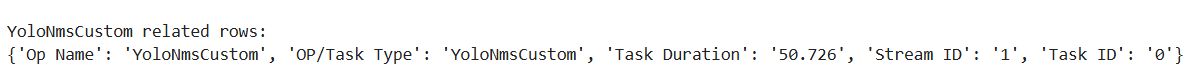

```text
在本实验输入规模 boxes=(51,4)、scores=(51,) 下，自定义 NMS 的功能正确性已由 PASSED 和 keep/count 对齐验证。
```

## 8. 本章小结

本章完成了 CPU NMS 与 NPU 自定义后处理算子的延迟对比和 Profiling 分析。可以按下面格式记录：

```text
输入规模：boxes=(51,4), scores=(51,)
CPU NMS 算法耗时：____ ms
ACLNN runner 端到端耗时：____ ms
MindStudio 中 YoloNmsCustom task/kernel 耗时：____ ms
正确性：custom keep/count 与 CPU reference 一致，PASSED
结论：当前实验已经完成 NPU 自定义 NMS 的功能验证，并通过 Profiling 得到算子级耗时。
```


## 课后练习

请根据本节实验内容完成以下练习。题型包含单选题、多选题、判断题、填空题、简答题和代码设计题。

1. (单选题) CPU NMS algorithm latency 与 ACLNN runner wall time 的关系最准确的是？
   - A. 二者完全等价
   - B. runner wall time 包含编译、数据生成、ACL 初始化、文件 I/O 等端到端开销，不等于 kernel 纯耗时
   - C. CPU latency 一定比 NPU kernel 慢
   - D. 二者都不能测量

2. (单选题) 想查看自定义算子 `YoloNmsCustom` 的真实任务耗时，应优先查看哪类 Profiling 输出？
   - A. op_summary_*.csv 或 MindStudio OP Info
   - B. README 标题
   - C. Git status
   - D. requirements.txt

3. (单选题) MSPROF 采集数据后，常见输出目录名前缀是？
   - A. PROF_
   - B. VOC_
   - C. JPEG_
   - D. GIT_

4. (单选题) 如果 Profiling 中 YoloNmsCustom 的 Task Duration 为 50.726 us，换算为毫秒约为？
   - A. 0.0507 ms
   - B. 50.726 ms
   - C. 50726 ms
   - D. 5.0726 s

5. (多选题) 撰写延迟对比结论时，应明确区分哪些时间？
   - A. CPU NMS 算法耗时
   - B. ACLNN runner 端到端耗时
   - C. Profiling 中 kernel/task 耗时
   - D. 数据准备和编译开销

6. (多选题) MindStudio Profiling / msprof 可以帮助观察哪些方面？
   - A. API 调用
   - B. Task Time
   - C. 算子统计
   - D. Host 侧瓶颈

7. (多选题) 如果 runner wall time 很长，可能包含哪些非 kernel 开销？
   - A. CMake/Make 编译
   - B. 输入文件生成和读取
   - C. ACL 初始化和同步
   - D. 输出文件写入

8. (判断题) 看到 runner wall time 比 CPU NMS 大，就能直接说明 NPU 自定义算子性能更差。

9. (判断题) Profiling 结果中若能找到 YoloNmsCustom 行，说明自定义算子进入了被采集的执行链路。

10. (填空题) 算子耗时字段 `Task Duration(us)` 的单位是 `____`。

11. (填空题) 本实验用于采集 Profiling 的命令行工具是 `____`。

12. (简答题) 为什么实验报告中不建议写“runner 14.59s，所以 NPU 比 CPU 慢”？

13. (简答题) MindStudio GUI 中分析自定义算子耗时的基本步骤是什么？

14. (简答题) 如果 Profiling 报告中找不到 YoloNmsCustom，可能是什么原因？

15. (代码设计题) 写一条 msprof 命令，对 PyACL YOLO 推理脚本采集 Profiling 数据。

> 参考答案见 answer/04.07_latency_comparison_and_profiling_answer.ipynb。
